# B1 – Sokoban : un jeu dans un tableau

**Python numérique – sujet bonus n° 1 – à rendre, si le cœur vous en dit, pour le vendredi 25 septembre 2026, 18 h** (en même temps que le D2)

Vous avez trouvé le niveau caché : bienvenue ! Ce sujet n'est pas un devoir. Il s'adresse à ceux qui ont terminé la séance 1 avec de l'avance et qui veulent un vrai morceau à se mettre sous la dent. Rien n'est obligatoire ; en revanche, un rendu complet donne un bonus sur votre contrôle continu, selon la règle habituelle des TP optionnels : il ne peut que faire monter la note.

Le *Sokoban* est un vieux jeu japonais (1982) où un gardien d'entrepôt pousse des caisses jusqu'à des cases d'arrivée. On ne peut que pousser, jamais tirer, et une seule caisse à la fois : c'est ce qui rend le jeu retors. Nous allons le coder de bout en bout avec les outils de la séance 1, c-à-d. des tableaux, des `dtype`, du slicing, des vues et des copies, puis nous écrirons un programme qui *résout* les niveaux tout seul. Les anciens de MPI reconnaîtront un parcours en largeur ; les autres le découvriront, et il tient en vingt lignes.

Durée indicative : 2 h, davantage si vous vous prenez au jeu.

````{admonition} Consignes de rendu
:class: important

* Ce notebook reste dans le dossier `B1/` de votre dépôt `pe-homework` (celui que le zip du sujet a créé en se dézippant), avec ses figures à côté, puis il doit être **commité et poussé** (`git add`, `git commit`, `git push`) avant la date indiquée. Attention, c'est la **date du commit** qui fait foi, pas celle du push ; le nom du fichier, lui, n'a pas d'importance (`sujet.ipynb` convient très bien).
* Juste avant de rendre, **pensez à ré-exécuter toutes les cellules** via *Kernel → Restart Kernel and Run All Cells* : toutes doivent s'exécuter dans l'ordre et sans erreur.
* Les images demandées (`sokoban.png`, `sokoban_film.png`) sont à enregistrer dans le dossier du notebook, et doivent aussi apparaître dans le notebook (`plt.imshow`).
* Les cellules `# votre code` sont à compléter ; vous pouvez ajouter autant de cellules que vous le souhaitez. Les cellules de test (`assert`) sont là pour vous aider : si elles passent sans erreur, c'est bon signe. Ne les modifiez pas !
* Répondez aux questions "en français" dans une cellule *Markdown*, en deux ou trois phrases.
````

````{admonition} Ce qui est autorisé
:class: note

* La documentation de `numpy` / `matplotlib`, les notebooks du cours, vos notes.
* Les assistants IA sont tolérés, avec la règle habituelle : **vous devez être capable d'expliquer chaque ligne que vous rendez**, et je pourrai vous demander de le faire à l'oral en séance. Le travail est individuel.
* Les boucles Python sur les cases d'un tableau sont interdites : lire un niveau, le dessiner, jouer un coup, tout se fait par slicing, masques et affectations globales. La seule boucle autorisée est celle qui enchaîne les coups (exercices 4 et 5) : elle est inévitable, puisque chaque coup dépend du précédent.
````

````{admonition} Si vous êtes coincé
:class: tip

Ce sujet est plus long et plus ouvert qu'un devoir, et il est normal d'y buter. Si vous êtes bloqué sur une question, même en dehors des séances, écrivez-moi : [aurelien.noce@minesparis.psl.eu](mailto:aurelien.noce@minesparis.psl.eu). Dites-moi où vous en êtes et ce que vous avez essayé, je vous donne un coup de pouce, pas la réponse.
````

## Barème

| Exercice | Contenu | Points |
|---|---|---|
| 1 | Lire et écrire un niveau | 4 |
| 2 | Dessiner le niveau, l'afficher | 3 |
| 3 | Jouer un coup | 5 |
| 4 | Gagné ? Rejouer une solution, le film | 2 |
| 5 | Le solveur | 4 |
| – | Notebook propre : exécuté sans erreur, réponses rédigées, figures titrées | 2 |
| **Total** | | **20** |
| Bonus | Les coins morts | +2 |

Le total sur 20 n'est là que pour vous situer : c'est lui qui est converti en bonus.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Les niveaux

Un niveau de Sokoban s'écrit traditionnellement en texte, un caractère par case, avec la convention suivante (c'est celle de tous les fichiers de niveaux que vous trouverez sur Internet) :

| caractère | `#` | espace | `.` | `$` | `*` | `@` | `+` |
|---|---|---|---|---|---|---|---|
| case | mur | sol | cible | caisse | caisse **sur** une cible | gardien | gardien **sur** une cible |

Voici les quatre niveaux dont nous nous servirons : ils sont rectangulaires, c-à-d. que toutes les lignes d'un niveau ont la même longueur. Le premier est minuscule, le dernier est un vrai casse-tête.

In [2]:
NIVEAU_1 = """
######
#   .#
# $  #
#  @ #
######
"""

NIVEAU_2 = """
#######
#  ####
#     #
## $  #
#  #.##
# @$ .#
#  ####
#######
"""

NIVEAU_3 = """
########
#  .   #
# $ #  #
#  $ . #
# .#$  #
#  @   #
########
"""

NIVEAU_4 = """
########
###   ##
#.@$  ##
### $.##
#.##$ ##
# #  .##
#$ *$$.#
#   .  #
########
"""

## Exercice 1 – Lire et écrire un niveau (4 pts)

Comment représenter un niveau en `numpy` ? On pourrait imaginer un seul tableau d'entiers avec un code par type de case, mais un souci apparaît vite : une caisse posée sur une cible, ou le gardien debout sur une cible, occupent la même case que la cible. Il faudrait alors un code pour chaque combinaison, et le jeu deviendrait pénible à écrire.

Nous allons donc plutôt séparer le niveau en *couches* (layers), c-à-d. plusieurs tableaux booléens de même forme `(H, W)`, un par type d'objet :

* `murs` : `True` là où il y a un mur ;
* `cibles` : `True` sur les cases d'arrivée ;
* `caisses` : `True` là où se trouve une caisse ;

et le gardien, qui est unique, sera simplement un couple d'entiers `joueur = (i, j)`. Les murs et les cibles ne bougent jamais : ce sont le *décor*. Les caisses et le gardien forment l'*état* du jeu, celui qui change à chaque coup.

````{admonition} Pas encore vu en cours : les comparaisons entre tableaux
:class: note

Une comparaison s'applique case par case et renvoie un tableau de booléens de même forme : `np.array(["a", "b", "a"]) == "a"` vaut `[True, False, True]`. On appelle cela un *masque*, et les masques se combinent case par case avec `&` (et), `|` (ou) et `~` (non) : attention, pas avec `and` / `or` / `not`, qui ne savent traiter qu'un seul booléen à la fois ! On travaillera les masques en séance 2.
````

````{admonition} Pas encore vu en cours : np.argwhere
:class: note

`np.argwhere(masque)` renvoie les coordonnées de toutes les cases `True`, sous forme d'un tableau `(k, 2)` : une ligne `[i, j]` par case trouvée. Ainsi `np.argwhere(np.array([[False, True], [True, False]]))` vaut `[[0, 1], [1, 0]]`.
````

**1.a** Écrivez `lire_niveau(texte)` qui renvoie le quadruplet `(murs, cibles, caisses, joueur)` à partir du texte d'un niveau. Un plan d'attaque :

1. découpez le texte en lignes (`texte.strip("\n").split("\n")`) ;
2. `np.array([list(ligne) for ligne in lignes])` fabrique un tableau `(H, W)` de caractères. Cette boucle-là est acceptée : elle porte sur les lignes du *texte*, pas sur les cases d'un tableau ;
3. les trois couches s'obtiennent chacune par une ou deux comparaisons de ce tableau avec un caractère ;
4. le gardien est l'unique case `@` ou `+` : `np.argwhere` vous donne ses coordonnées. Renvoyez-les sous forme d'un `tuple` de deux `int` Python (`tuple(int(c) for c in ...)`) : nous verrons à l'exercice 3 pourquoi ce détail compte.

Quel est le `dtype` du tableau de caractères ? Et celui des couches ?

In [3]:
# votre code
def lire_niveau(texte):
    lignes = texte.strip("\n").split("\n")
    grille = np.array([list(ligne) for ligne in lignes])
    joueur = (int(np.argwhere((grille == "@") | (grille == "+"))[0, 0]), int(np.argwhere(grille == "@")[0, 1]))
    return (grille == "#", (grille == ".") | (grille == "*") | (grille == "+"), (grille == "$") | (grille == "*"), joueur)

In [4]:
murs, cibles, caisses, joueur = lire_niveau(NIVEAU_1)
assert murs.shape == cibles.shape == caisses.shape == (5, 6)
assert murs.dtype == cibles.dtype == caisses.dtype == bool
assert murs.sum() == 18 and cibles.sum() == 1 and caisses.sum() == 1
assert cibles[1, 4] and caisses[2, 2]
assert type(joueur) is tuple and all(type(c) is int for c in joueur), "joueur doit être un tuple de deux int Python"
assert joueur == (3, 3)

murs4, cibles4, caisses4, joueur4 = lire_niveau(NIVEAU_4)
assert murs4.shape == (9, 8)
assert cibles4.sum() == 7 and caisses4.sum() == 7, "une caisse sur une cible compte dans les deux couches"
assert cibles4[6, 3] and caisses4[6, 3]
assert type(joueur4) is tuple and joueur4 == (2, 2)
print("ok")

ok


**1.b** Faites le chemin inverse : `ecrire_niveau(murs, cibles, caisses, joueur)` renvoie le texte du niveau, avec la même convention. Partez d'un tableau `(H, W)` rempli d'espaces (`np.full(murs.shape, " ")`), puis posez les caractères couche par couche, en terminant par les cas composés (`*`, `+`) et par le gardien. Pour finir, recollez les lignes avec `"".join(...)` et `"\n".join(...)`.

````{admonition} Pas encore vu en cours : affecter à travers un masque
:class: note

Un masque booléen peut servir d'indice : `grille[masque] = "#"` écrit `"#"` dans toutes les cases où `masque` vaut `True`, et laisse les autres tranquilles. C'est l'écriture vectorisée de « pour chaque case où… ». Nous y reviendrons en séance 2.
````

In [5]:
# votre code
def ecrire_niveau(murs, cibles, caisses, joueur):
    grille = np.full(murs.shape, " ")
    grille[murs] = "#"
    grille[cibles] = "."
    grille[caisses] = "$"
    grille[caisses & cibles] = "*"
    masque_gardien = np.full(murs.shape, False)
    masque_gardien[joueur] = True
    if np.any(cibles & masque_gardien):
        grille[cibles & masque_gardien] = "+"
    else:
        grille[masque_gardien] = "@"
    return "\n".join(["".join(ligne) for ligne in grille])  # ici la boucle porte toujours sur les lignes du texte

In [6]:
for texte in (NIVEAU_1, NIVEAU_2, NIVEAU_3, NIVEAU_4):
    assert np.all(ecrire_niveau(*lire_niveau(texte)) == texte.strip("\n")), "l'aller-retour doit redonner le texte"
print("ok")

ok


## Exercice 2 – Dessiner le niveau (3 pts)

Le texte, c'est bien pour stocker ; pour regarder, une image est plus agréable. Comme dans le D1, une image couleur est un tableau `(H, W, 3)` d'entiers `uint8`. Voici une palette :

| objet | (R, G, B) |
|---|---|
| sol | (236, 233, 220) |
| mur | (70, 70, 80) |
| cible | (250, 210, 40) |
| caisse | (160, 100, 40) |
| caisse sur une cible | (40, 170, 70) |
| gardien | (220, 30, 30) |

**2.a** Écrivez `dessiner(murs, cibles, caisses, joueur, zoom=24)` qui construit l'image du niveau, une couleur par case, puis l'agrandit d'un facteur `zoom` dans les deux directions avec `np.repeat` (comme au D1), et **renvoie le tableau** `(H * zoom, W * zoom, 3)` en `uint8`. La fonction n'affiche rien et n'enregistre rien : elle fabrique l'image, c'est tout. En effet, nous la rappellerons des dizaines de fois à l'exercice 4 pour fabriquer un film, et il serait pénible qu'elle ouvre une figure à chaque appel. Posez les couleurs couche par couche : `img[murs] = (70, 70, 80)` colorie d'un coup toutes les cases de mur, car `numpy` "étire" le triplet sur les trois canaux de chaque case sélectionnée.

In [7]:
# votre code
def dessiner(murs, cibles, caisses, joueur, zoom=24):
    (h, w) = murs.shape
    img = np.empty((h, w, 3), dtype=np.uint8)
    img[:] = (236, 233, 220)
    img[murs] = (70, 70, 80)
    img[cibles] = (250, 210, 40)
    img[caisses] = (160, 100, 40)
    img[cibles & caisses] = (40, 170, 70)
    img[joueur] = (220, 30, 30)
    img = np.repeat(img, zoom, axis=0)
    img = np.repeat(img, zoom, axis=1)
    return img

In [8]:
figures_avant = len(plt.get_fignums())
img = dessiner(*lire_niveau(NIVEAU_1))
assert len(plt.get_fignums()) == figures_avant, "dessiner ne doit ouvrir aucune figure : elle renvoie l'image, c'est tout"
assert img.shape == (5 * 24, 6 * 24, 3) and img.dtype == np.uint8
assert tuple(img[0, 0]) == (70, 70, 80), "en haut à gauche, un mur"
assert tuple(img[3 * 24, 3 * 24]) == (220, 30, 30), "le gardien"
assert tuple(img[2 * 24 + 5, 2 * 24 + 5]) == (160, 100, 40), "la caisse, jusque dans le coin de sa case"
img4 = dessiner(*lire_niveau(NIVEAU_4), zoom=1)
assert img4.shape == (9, 8, 3)
assert tuple(img4[6, 3]) == (40, 170, 70), "une caisse déjà sur sa cible"
print("ok")

ok


**2.b** Maintenant seulement, affichez les quatre niveaux avec `plt.imshow` (une figure chacun, avec un titre) et enregistrez l'image du niveau 4 dans `sokoban.png` avec `plt.imsave`.

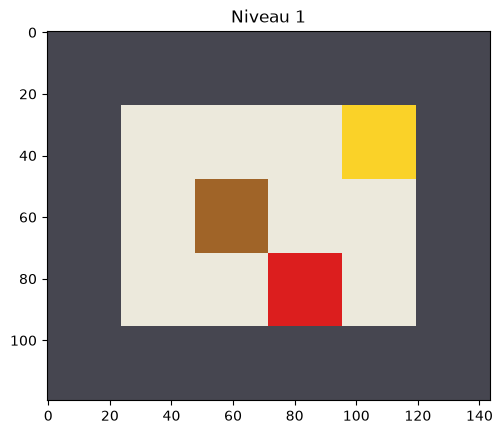

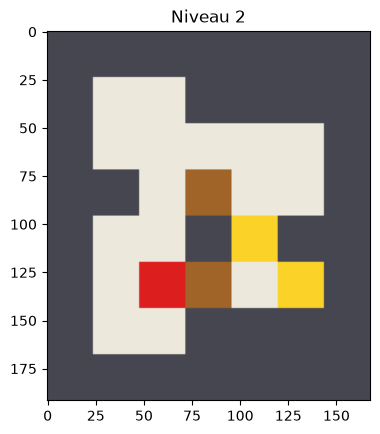

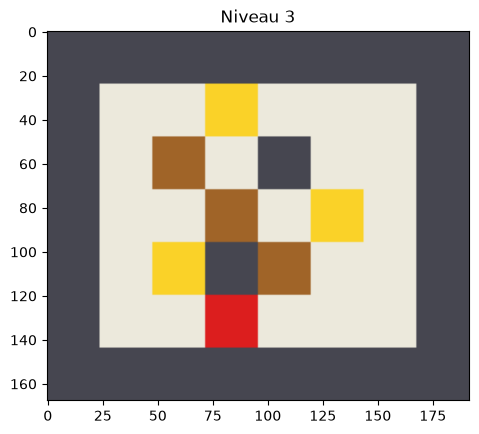

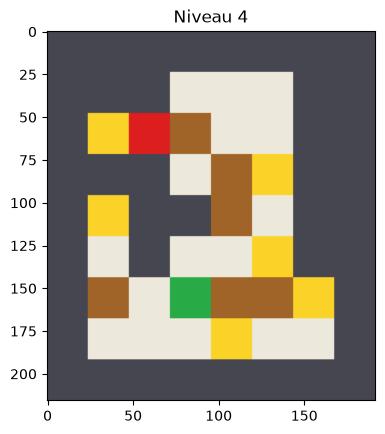

In [9]:
# votre code
plt.title("Niveau 1")
plt.imshow(dessiner(*lire_niveau(NIVEAU_1)))
plt.show()

plt.title("Niveau 2")
plt.imshow(dessiner(*lire_niveau(NIVEAU_2)))
plt.show()

plt.title("Niveau 3")
plt.imshow(dessiner(*lire_niveau(NIVEAU_3)))
plt.show()

plt.title("Niveau 4")
plt.imshow(dessiner(*lire_niveau(NIVEAU_4)))
plt.show()
plt.imsave("sokoban.png", dessiner(*lire_niveau(NIVEAU_4)))

In [10]:
import os
assert os.path.exists("sokoban.png")
print("ok")

ok


## Exercice 3 – Jouer un coup (5 pts)

Voici le cœur du jeu. Un coup est une direction parmi quatre, que nous coderons par une lettre : `h` (haut), `b` (bas), `g` (gauche), `d` (droite), avec les déplacements correspondants sur les indices `(i, j)` :

In [11]:
DIRECTIONS = {"h": (-1, 0), "b": (1, 0), "g": (0, -1), "d": (0, 1)}

Les règles sont simples :

* le gardien tente d'avancer d'une case dans la direction donnée ;
* si cette case est un mur, rien ne se passe ;
* si cette case contient une caisse, la caisse est poussée d'une case dans la même direction, à condition que la case d'au-delà soit libre (ni mur, ni caisse) ; sinon rien ne se passe ;
* sinon le gardien avance, tout simplement.

**3.a** Écrivez `jouer(murs, caisses, joueur, direction)` qui renvoie le nouvel état `(caisses, joueur)` après le coup. Si le coup est impossible, l'état renvoyé est identique à l'état reçu.

Une règle impérative, et c'est là que la séance 1 se joue : **la fonction ne doit pas modifier le tableau `caisses` qu'elle reçoit**. En effet, le solveur de l'exercice 5 va explorer des milliers de coups à partir d'un même état ; si `jouer` déplace la caisse "en place", l'état de départ est corrompu et tout s'effondre. Quand une caisse bouge, faites d'abord une copie (`.copy()`), et modifiez la copie. Lorsque rien ne bouge, inutile de copier : renvoyer le tableau reçu convient très bien.

````{admonition} Piège : un tuple n'est pas un tableau
:class: warning

Pour indexer une case, `caisses[i, j]` et `caisses[(i, j)]` sont la même chose, un *tuple* d'indices. Mais `caisses[np.array([i, j])]` est tout autre chose : un tableau d'indices sélectionne des **lignes** entières, ici les lignes `i` et `j` ! De même, additionner deux tuples les *concatène* (`(3, 3) + (0, 1)` vaut `(3, 3, 0, 1)`), alors qu'additionner deux tableaux additionne case par case. Il faut donc choisir : calculer les positions comme des tableaux (`np.array(joueur) + np.array(delta)`), puis les reconvertir en tuple avant d'indexer, ou bien tout écrire en arithmétique sur les deux entiers. Pouvez-vous deviner ce que renvoie `caisses[np.array([1, 2])].shape` sur le niveau 1 ? Vérifiez.
````

In [12]:
# votre code
def jouer(murs, caisses, joueur, direction):
    coord_dir = DIRECTIONS[direction]
    nv_pos = (joueur[0] + coord_dir[0], joueur[1] + coord_dir[1])
    if not murs[nv_pos]:
        if caisses[nv_pos]:
            nv_pos_caisse = (nv_pos[0] + coord_dir[0], nv_pos[1] + coord_dir[1])
            if not (murs[nv_pos_caisse] or caisses[nv_pos_caisse]):
                caisses_copie = caisses.copy()
                caisses_copie[nv_pos] = False
                caisses_copie[nv_pos_caisse] = True
                return (caisses_copie, nv_pos)
        else:
            return (caisses, nv_pos)
    return (caisses, joueur)

In [13]:
murs, cibles, caisses, joueur = lire_niveau(NIVEAU_1)
avant = caisses.copy()

# un pas vers le bas : c'est un mur, rien ne bouge
c, p = jouer(murs, caisses, joueur, "b")
assert type(p) is tuple, "la position renvoyée doit rester un tuple (i, j)"
assert p == (3, 3) and np.array_equal(c, avant)

# vers la gauche : le sol est libre, le gardien avance
c, p = jouer(murs, caisses, joueur, "g")
assert p == (3, 2) and np.array_equal(c, avant)

# depuis (3, 2), vers le haut : la caisse en (2, 2) est poussée en (1, 2)
c2, p2 = jouer(murs, c, p, "h")
assert p2 == (2, 2) and c2[1, 2] and not c2[2, 2] and c2.sum() == 1
assert np.array_equal(caisses, avant), "jouer ne doit pas modifier le tableau reçu"
assert not np.shares_memory(c2, caisses), "le nouvel état doit être une copie"

# la caisse est contre le mur du haut : impossible de la pousser davantage
c3, p3 = jouer(murs, c2, p2, "h")
assert p3 == p2 and np.array_equal(c3, c2)

# deux caisses à la file ne se poussent pas : niveau 4, gardien posé en (6, 2),
# caisse en (6, 3) et une autre juste derrière en (6, 4)
murs4, cibles4, caisses4, joueur4 = lire_niveau(NIVEAU_4)
c4, p4 = jouer(murs4, caisses4, (6, 2), "d")
assert p4 == (6, 2) and np.array_equal(c4, caisses4)
print("ok")

ok


## Exercice 4 – Gagné ? Rejouer une solution, le film (2 pts)

**4.a** Écrivez `gagne(cibles, caisses)`, qui renvoie `True` quand toutes les caisses sont sur des cibles. Une ligne suffit : quelle relation lie alors les deux couches ?

**4.b** Écrivez `rejouer(niveau, coups)` qui, à partir du texte d'un niveau et d'une chaîne de coups comme `"ghghdd"`, joue les coups l'un après l'autre (c'est la boucle autorisée) et renvoie la liste des états successifs `[(caisses, joueur), ...]`, état initial compris.

In [14]:
# votre code
def gagne(cibles, caisses):
    return np.array_equal(cibles, caisses)  # Les deux tableaux doivent être identiques en contenu

def rejouer(niveau, coups):
    murs, cibles, caisses, joueur = lire_niveau(niveau)
    liste_etats = [(caisses, joueur)]
    for s in coups:
        caisses, joueur = jouer(murs, caisses, joueur, s)
        liste_etats.append((caisses, joueur))
    return liste_etats

In [15]:
murs, cibles, caisses, joueur = lire_niveau(NIVEAU_1)
assert not gagne(cibles, caisses)
etats = rejouer(NIVEAU_1, "ghghdd")
assert len(etats) == 7
assert gagne(cibles, etats[-1][0]) and tuple(etats[-1][1]) == (1, 3)
assert not gagne(cibles, etats[-2][0])
assert np.array_equal(etats[0][0], caisses), "l'état initial ne doit pas avoir bougé"
print("ok")

ok


````{admonition} Pas encore vu en cours : np.concatenate
:class: note

`np.concatenate([a, b, c], axis=1)` prend une *liste* de tableaux et les met bout à bout le long d'un axe, dans un nouveau tableau. Avec `axis=1`, ils sont posés côte à côte : les tableaux doivent alors avoir la même taille sur tous les autres axes (même hauteur, même nombre de canaux), et les largeurs s'additionnent. Ainsi, trois images `(120, 144, 3)` concaténées sur l'axe 1 donnent une image `(120, 432, 3)`. Avec `axis=0`, ils sont empilés l'un sous l'autre, et ce sont les hauteurs qui s'additionnent. Le résultat garde le `dtype` des tableaux de départ, ici `uint8`.
````

**4.c** Le film. Fabriquez, avec `dessiner` et `np.concatenate`, une seule image large `film` qui montre côte à côte les sept états de la solution `"ghghdd"` du niveau 1, avec une colonne blanche de 4 pixels de large entre deux images, pour qu'on les distingue. Concrètement :

* dessinez chaque état de `rejouer(NIVEAU_1, "ghghdd")` : sept images `(120, 144, 3)` ;
* fabriquez le séparateur, une image toute blanche de même hauteur et de 4 pixels de large : `np.full((120, 4, 3), 255, dtype=np.uint8)` (le `dtype` compte, sinon la concaténation avec vos images `uint8` produirait des flottants) ;
* construisez la liste des morceaux dans l'ordre, image, séparateur, image, séparateur, … en terminant par une image (six séparateurs pour sept images), puis concaténez-la sur l'axe 1.

Vérifiez la forme obtenue avant de passer aux tests : quelle largeur attendez-vous ? Affichez ensuite le film avec un titre et enregistrez-le dans `sokoban_film.png`.

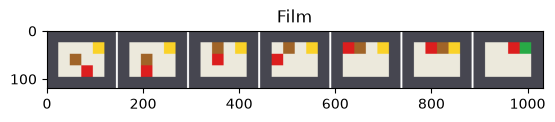

In [16]:
# votre code
murs, cibles, caisses, joueur = lire_niveau(NIVEAU_1)
liste_etats = rejouer(NIVEAU_1, "ghghdd")
film = dessiner(murs, cibles, caisses, joueur)
for (caisses, joueur) in liste_etats[1:]:
    img = dessiner(murs, cibles, caisses, joueur)
    film = np.concatenate([film, np.full((120, 4, 3), 255, dtype=np.uint8), img], axis=1)

plt.title("Film")
plt.imshow(film)
plt.show()
plt.imsave("sokoban_film.png", film)

On s'attend à avoir une image de largeur 7*144 + 6 * 4, soit de largeur 1032 px.

In [17]:
assert film.shape[1] == 1032
print("C'est bien le cas.")

C'est bien le cas.


In [18]:
assert film.dtype == np.uint8 and film.ndim == 3
assert film.shape[0] == 5 * 24
assert film.shape[1] == 7 * 6 * 24 + 6 * 4
assert os.path.exists("sokoban_film.png")
print("ok")

ok


## Exercice 5 – Le solveur (4 pts)

Passons à la partie la plus amusante : faire résoudre les niveaux par la machine. Certains d'entre vous ont déjà vu un *parcours en largeur* (breadth-first search, BFS) en prépa ; pour les autres, voici l'idée, qui tient en quelques lignes.

Un *état* du jeu, c'est la position des caisses et celle du gardien : le couple `(caisses, joueur)` de l'exercice 3. Depuis un état, quatre coups sont possibles, qui mènent chacun à un état voisin (parfois le même, si le coup est impossible). Résoudre le niveau, c'est trouver un chemin de l'état initial à un état gagnant. Le parcours en largeur s'y prend comme une onde qui se propage : il regarde d'abord tous les états atteignables en un coup, puis tous ceux atteignables en deux coups, et ainsi de suite, jusqu'à tomber sur un état gagnant. Comme on explore par nombre de coups croissant, la première solution trouvée est la plus courte. Pour organiser cela, il suffit de deux structures :

* une *file d'attente* des états à visiter, qu'on prend dans l'ordre d'arrivée (premier entré, premier sorti). Au départ elle contient l'état initial ; chaque fois qu'on sort un état, on y ajoute ses voisins pas encore vus. `collections.deque` est faite pour ça : `append` ajoute à droite, `popleft` retire à gauche ;
* un dictionnaire `vus` des états déjà rencontrés, qui associe à chacun la chaîne des coups qui y mène depuis le départ. Il sert à deux choses : ne jamais revisiter un état (sinon on tourne en rond), et retrouver la solution une fois l'état gagnant sorti de la file, puisque le chemin y est déjà.

Il reste une question : comment mettre un état dans un dictionnaire ? Un tableau `numpy` ne peut pas servir de clé, il n'est pas *hachable*. Le remède est classique :

````{admonition} Pas encore vu en cours : tobytes
:class: note

`tab.tobytes()` renvoie le contenu brut du tableau, c-à-d. son segment mémoire, sous forme d'un objet `bytes` Python. Deux tableaux de même forme et de même contenu donnent les mêmes `bytes`, et un `bytes` est hachable : `(caisses.tobytes(), joueur)` est donc une clé de dictionnaire parfaite pour un état. Retenez bien que `tobytes` ne mémorise pas la forme : nos couches ont toutes la même, donc ici cela n'a aucune importance.
````

````{admonition} Bonnes pratiques : le solveur reste vectorisé
:class: tip

Le parcours va visiter des dizaines de milliers d'états, et chaque état est un tableau. C'est là qu'on voit si l'on a pris le pli `numpy` :

* **aucune boucle sur les cases.** Les deux seules boucles Python du solveur sont celle qui vide la file et celle sur les quatre directions. Tout ce qui touche au contenu d'un tableau passe par une opération globale : « gagné ? » se teste avec `np.array_equal(cibles, caisses)` (exercice 4), pas en parcourant la grille ; « ce coup a-t-il bougé le gardien ? » se teste en comparant les deux tuples de position ;
* **copier seulement quand c'est nécessaire.** Votre `jouer` de l'exercice 3 ne copie `caisses` que si une caisse bouge : c'est exactement ce qu'il faut ici. Une copie systématique multiplierait le travail par quatre sans rien changer au résultat ;
* **la clé se calcule une fois par état**, et jamais en convertissant le tableau en liste ou en chaîne : `tobytes()` est immédiat, `str(tab)` ou `tab.tolist()` sont cent fois plus lents.
````

**5.a** Complétez `resoudre(niveau)` ci-dessous, qui renvoie le couple `(coups, nb_etats)` : la chaîne des coups d'une solution la plus courte, et le nombre d'états sortis de la file avant de la trouver (il servira au bonus). Le parcours est déjà écrit ; il vous reste trois trous, marqués `...` :

1. `cle(caisses, joueur)`, qui transforme un état en clé de dictionnaire, cf. l'encart ;
2. le test d'arrêt : si l'état qui vient de sortir de la file est gagnant, on renvoie son chemin ;
3. la boucle sur les quatre directions : jouer le coup, ignorer ceux qui ne bougent pas le gardien (l'état est identique, il est déjà dans `vus`), puis, pour un état jamais vu, l'inscrire dans `vus` avec son chemin (`chemin + direction`) et l'ajouter à la file.

```python
from collections import deque

def resoudre(niveau):
    murs, cibles, caisses, joueur = lire_niveau(niveau)

    def cle(caisses, joueur):
        return ...

    vus = {cle(caisses, joueur): ""}          # état -> chaîne des coups qui y mène
    file = deque([(caisses, joueur)])
    nb_etats = 0
    while file:
        caisses, joueur = file.popleft()
        nb_etats += 1
        chemin = vus[cle(caisses, joueur)]
        if ...:                               # gagné ?
            return chemin, nb_etats
        for direction in DIRECTIONS:
            ...                               # jouer, filtrer, enregistrer
    return None, nb_etats                     # niveau sans solution
```

Testez sur les niveaux 1 à 3 : le niveau 1 se résout en 6 coups, le 2 en 10, le 3 en 25. Le niveau 3 demande quelques dizaines de milliers d'états, comptez une seconde ou deux ; si cela prend une minute, c'est qu'une copie ou une conversion de trop se cache dans la boucle.

In [19]:
# votre code
from collections import deque

def resoudre(niveau):
    murs, cibles, caisses, joueur = lire_niveau(niveau)

    def cle(caisses, joueur):
        return (caisses.tobytes(), joueur)

    vus = {cle(caisses, joueur): ""}          # état -> chaîne des coups qui y mène
    file = deque([(caisses, joueur)])
    nb_etats = 0
    while file:
        caisses, joueur = file.popleft()
        nb_etats += 1
        chemin = vus[cle(caisses, joueur)]
        if gagne(cibles, caisses):                               # gagné ?
            return chemin, nb_etats
        for direction in DIRECTIONS:
            c, j = jouer(murs, caisses, joueur, direction)       # jouer, filtrer, enregistrer
            if (not np.array_equal(c, j)) and j != joueur:
                key = cle(c, j)
                if key not in vus:
                    vus[key] = chemin + direction
                    file.append((c, j))
    return None, nb_etats                     # niveau sans solution

In [20]:
def verifie(niveau, coups, longueur):
    murs, cibles, caisses, joueur = lire_niveau(niveau)
    assert len(coups) == longueur, f"une solution la plus courte fait {longueur} coups, pas {len(coups)}"
    assert gagne(cibles, rejouer(niveau, coups)[-1][0]), "la solution rejouée ne gagne pas"

coups1, nb1 = resoudre(NIVEAU_1)
verifie(NIVEAU_1, coups1, 6)
coups2, nb2 = resoudre(NIVEAU_2)
verifie(NIVEAU_2, coups2, 10)
coups3, nb3 = resoudre(NIVEAU_3)
verifie(NIVEAU_3, coups3, 25)
assert nb1 < nb2 < nb3
print("ok")

ok


Les assert permettent la vérification pour les niveaux 1, 2 et 3.

**5.b** Rejouez la solution du niveau 3 et affichez l'état final (avec `dessiner`). Puis, dans une cellule Markdown : combien d'états différents le solveur a-t-il explorés pour ce niveau ? Et combien d'états possibles y a-t-il au maximum, en comptant grossièrement (nombre de façons de placer 3 caisses sur les cases de sol, multiplié par les positions du gardien) ? Que vous inspire le rapport entre les deux ?

40515


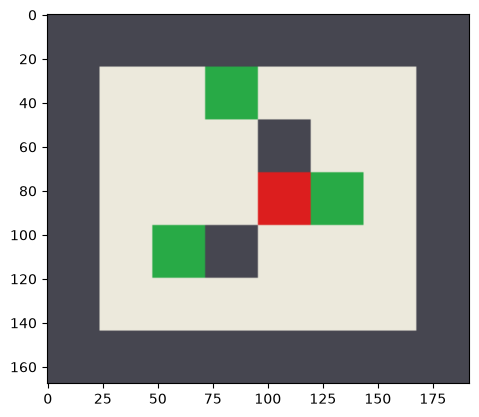

In [21]:
# votre code
(coups, nb_etats) = resoudre(NIVEAU_3)
liste_etats = rejouer(NIVEAU_3, coups)
murs, cibles, c, j = lire_niveau(NIVEAU_3)
plt.imshow(dessiner(murs, cibles, liste_etats[-1][0], liste_etats[-1][1]));
print(nb_etats)

D'après la valeur affichée par resoudre, 40515 états différents ont été explorés par le solveur pour ce niveau.
Sachant en outre qu'il y a 28 cases disponibles (hors murs), il y a 3276 façons de placer les 3 caisses ; multipliées par les 25 positions possibles du gardien, il y a <b>81900</b> états possibles au maximum. Le rapport est de l'ordre de $\frac{1}{2}$ : la moitié des états possibles ont été explorés.

## Bonus (+2) – Les coins morts

Le niveau 4 est petit, mais il résiste : le solveur de l'exercice 5 y explore environ un million d'états (une poignée de secondes, essayez). Or une bonne partie de ces états est perdue d'avance. En effet, une caisse poussée dans un *coin* (deux murs adjacents) ne pourra plus jamais en sortir, puisqu'on ne peut que pousser ; si ce coin n'est pas une cible, la partie est fichue. Inutile, donc, d'explorer au-delà.

**B.1** Écrivez `coins_morts(murs, cibles)` qui renvoie un masque `(H, W)` vrai sur les cases de sol qui ne sont pas des cibles et qui ont un mur au-dessus *ou* en dessous, *et* un mur à gauche *ou* à droite. Tout se fait par slicing, sans boucle, en comparant `murs` avec lui-même décalé d'une case dans chaque direction. Une astuce évite les cas particuliers du bord : fabriquez d'abord `m`, une version de `murs` entourée d'une ceinture de murs (`np.ones((H + 2, W + 2), dtype=bool)` dans laquelle vous recopiez `murs` au centre, par slicing) ; alors `m[:-2, 1:-1]` est la couche « mur au-dessus », `m[2:, 1:-1]` la couche « mur en dessous », et ainsi de suite.

**B.2** Ajoutez à `resoudre` un paramètre `interdit=None` : quand il est fourni, un coup qui pousse une caisse sur une case interdite est ignoré. Là encore, pas de boucle : « une caisse est-elle sur une case interdite ? » se demande d'un coup à tout le tableau, avec `(caisses & interdit).any()`. Comparez alors, sur le niveau 4, le nombre d'états explorés avec et sans les coins morts, et vérifiez que la solution reste de la même longueur (pourquoi est-ce garanti ?).

In [22]:
# votre code

In [23]:
murs, cibles, caisses, joueur = lire_niveau(NIVEAU_4)
morts = coins_morts(murs, cibles)
assert morts.dtype == bool and morts.shape == murs.shape
assert morts.sum() == 6
assert morts[1, 3] and morts[1, 5] and morts[3, 3] and morts[5, 3] and morts[7, 1] and morts[7, 6]
assert not morts[2, 1], "une cible n'est jamais un coin mort"
assert not (morts & murs).any()
verifie(NIVEAU_4, coups4, 38)
verifie(NIVEAU_4, coups4b, 38)
assert nb4b < nb4 / 5, "les coins morts doivent diviser l'exploration par cinq au moins"
print("ok")

NameError: name 'coins_morts' is not defined

Bon courage à tous, et bon jeu ! Pour toute question sur le sujet, vous pouvez me contacter par email : [aurelien.noce@minesparis.psl.eu](mailto:aurelien.noce@minesparis.psl.eu).

Au plaisir de vous lire,

votre responsable de cours, Aurélien Noce

In [ ]:
# votre code